In [23]:
import numpy as np
from matplotlib import pyplot as plt
import scipy
import os
import torch
import seaborn as sns

In [24]:
np.random.seed(10212)

dim_input = 100
dim_class = 50


def label_smoothing(y, r=0.9):
    return np.ones_like(y) * (1 - r) / y.shape[0] + y * r


def get_W_K(y_k: list[int], X: np.ndarray, lr=10):
    W_t = np.random.randn(dim_class, dim_input)
    y = np.zeros((dim_class, 1))
    for i in range(len(y_k)):
        y[y_k[i]] = 1
    probs_t = scipy.special.softmax(W_t.dot(X), axis=0)
    W_t1 = W_t - lr * np.outer((probs_t - y), X)
    return W_t1


def zo_step(W_t, X, seeds: list[int], mu=1e-4, plus=21, plus_lr=0):
    y = np.zeros((dim_class, 1))
    y[plus] = 1
    y = label_smoothing(y, 1)

    def loss(W, y):
        logits = W.dot(X)
        # num_class * batch
        probs_t = scipy.special.softmax(W.dot(X), axis=0)
        return -np.log(y.T @ probs_t)[0]  # single float

    zo_grad = 0
    for seed in seeds:
        np.random.seed(seed)
        pert = np.random.randn(*W_t.shape)
        W_plus = W_t + mu * pert
        l_plus = loss(W_plus, y)
        W_minus = W_t - mu * pert
        l_minus = loss(W_minus, y)

        zo_dir = (l_plus - l_minus) / 2 / mu
        zo_grad += zo_dir * pert

    W_t1 = W_t - plus_lr * zo_grad / len(seeds)
    probs_t = scipy.special.softmax(W_t.dot(X), axis=0)
    probs_t1 = scipy.special.softmax(W_t1.dot(X), axis=0)
    return probs_t.squeeze(), probs_t1.squeeze()


def fo_step(W_t, X, plus=42, plus_lr=0, minus=21, minus_lr=0):
    logits = W_t.dot(X)
    y = np.zeros((dim_class, 1))
    y[minus] = 1
    y = label_smoothing(y, 1)

    y2 = np.zeros((dim_class, 1))
    y2[plus] = 1
    y2 = label_smoothing(y2, 1)

    probs_t = scipy.special.softmax(W_t.dot(X), axis=0)
    W_t1 = (
        W_t
        + minus_lr * np.outer((probs_t * 1 - y), X)
        - plus_lr * np.outer((probs_t - y2), X)
    )
    probs_t1 = scipy.special.softmax(W_t1.dot(X), axis=0)
    return probs_t.squeeze(), probs_t1.squeeze()

In [25]:
X = np.random.randn(dim_input, 1)
Wt_uniform = np.random.randn(dim_class, dim_input)
Wt_peaky = get_W_K(list(range(15, 22)), X, lr=1)

In [26]:
fo_probs_t, fo_probs_t1 = fo_step(W_t=Wt_uniform, X=X, plus=9, plus_lr=0.5)
zo_probs_t, zo_probs_t1 = zo_step(
    W_t=Wt_uniform, X=X, seeds=range(20, 30), plus=9, plus_lr=0.5
)

In [27]:
def plot(prob, prob_next, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    x_axis = np.arange(0, len(prob))
    ax.step(x_axis, prob)
    ax.step(x_axis, prob_next)
    ax.set_yscale("log")
    return ax

<Axes: >

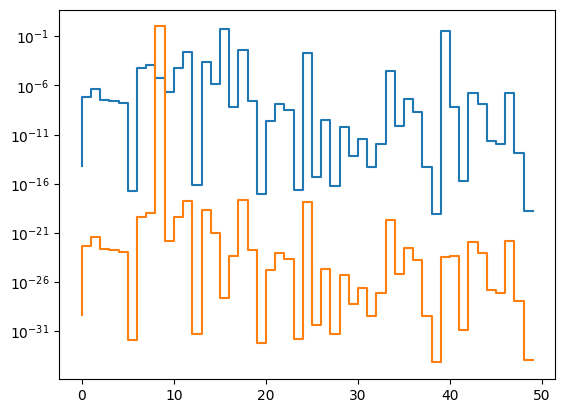

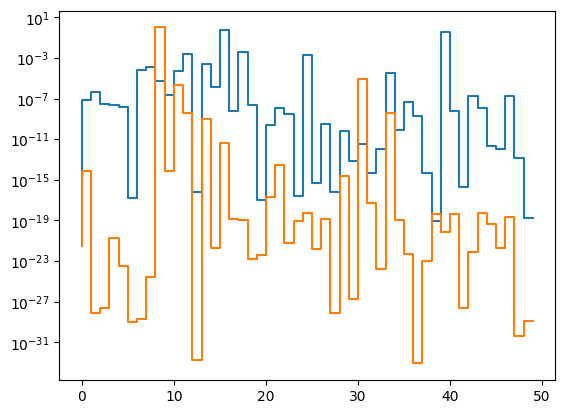

In [28]:
plot(fo_probs_t, fo_probs_t1)
plot(zo_probs_t, zo_probs_t1)

# The impact of the number of perturbations

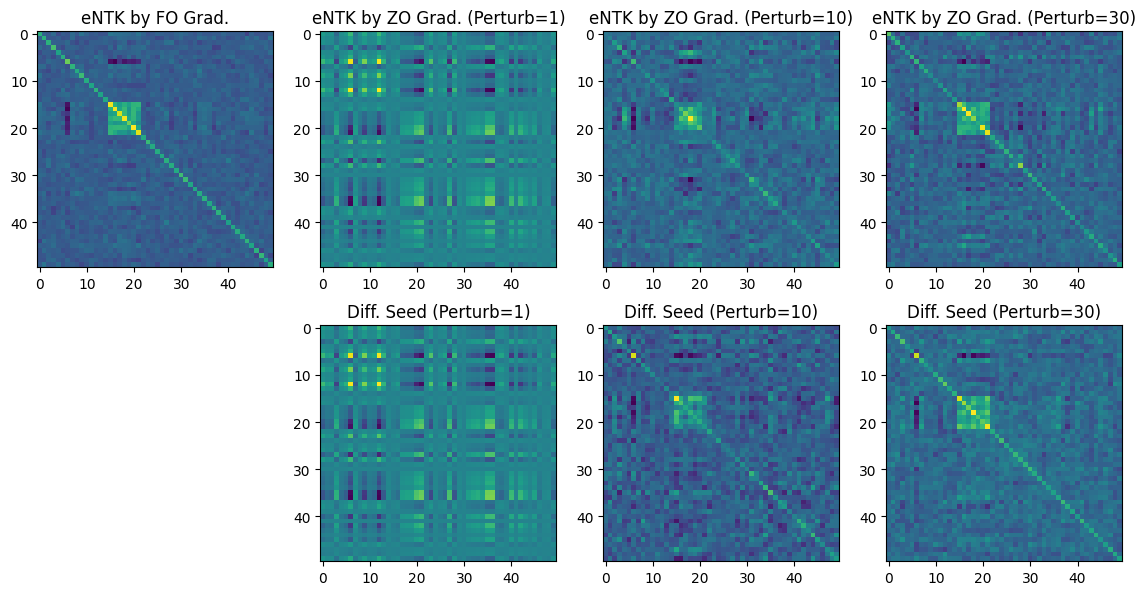

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(Wt_peaky @ Wt_peaky.T)
axes[0, 0].set_title("eNTK by FO Grad.")
axes[1, 0].axis("off")

for i, perturb in enumerate([1, 10, 30]):
    np.random.seed(10086 + i)
    u = np.random.randn(dim_input, perturb)
    axes[0, i + 1].imshow(Wt_peaky @ u @ u.T @ Wt_peaky.T)
    axes[0, i + 1].set_title(f"eNTK by ZO Grad. (Perturb={perturb})")

    np.random.seed(10086 + i * 2)
    u = np.random.randn(dim_input, perturb)
    axes[1, i + 1].imshow(Wt_peaky @ u @ u.T @ Wt_peaky.T)
    axes[1, i + 1].set_title(f"Diff. Seed (Perturb={perturb})")

# The impact of perturbation distribution

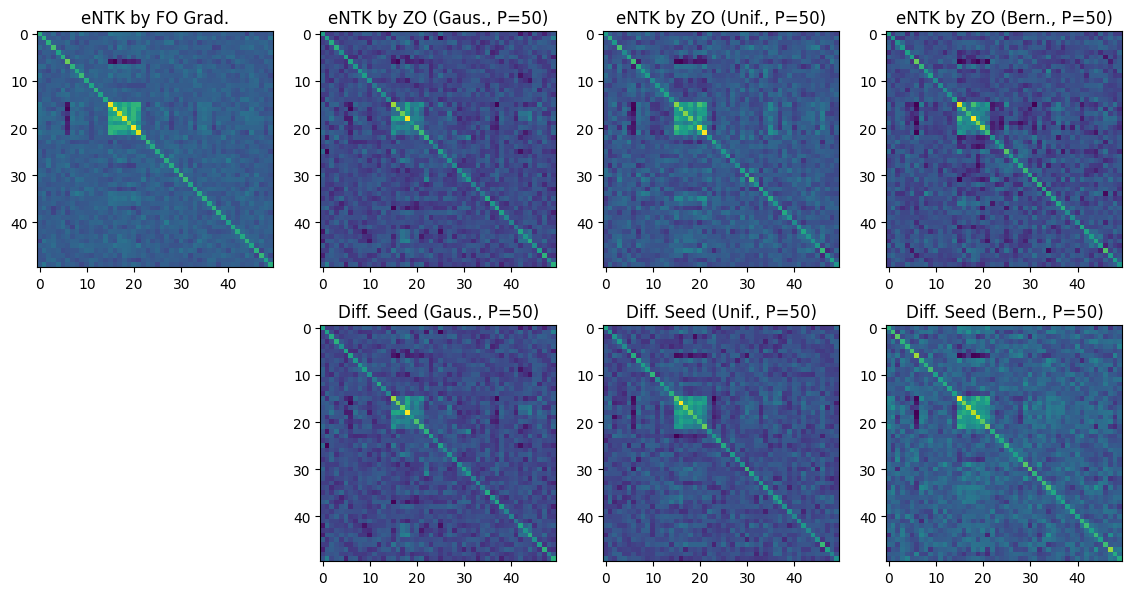

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(Wt_peaky @ Wt_peaky.T)
axes[0, 0].set_title("eNTK by FO Grad.")
axes[1, 0].axis("off")

PERT = 50

for i, dist in enumerate(["Gaus.", "Unif.", "Bern."]):
    np.random.seed(10086 + i)
    if dist == "Gaus.":
        u = np.random.randn(dim_input, PERT)
    elif dist == "Unif.":
        u = np.random.uniform(-1, 1, size=(dim_input, PERT))
    elif dist == "Bern.":
        u = np.random.choice([-1, 1], size=(dim_input, PERT))
    axes[0, i + 1].imshow(Wt_peaky @ u @ u.T @ Wt_peaky.T)
    axes[0, i + 1].set_title(f"eNTK by ZO ({dist}, P={PERT})")

    np.random.seed(10086 + i * 3)
    if dist == "Gaus.":
        u = np.random.randn(dim_input, PERT)
    elif dist == "Unif.":
        u = np.random.uniform(-1, 1, size=(dim_input, PERT))
    elif dist == "Bern.":
        u = np.random.choice([-1, 1], size=(dim_input, PERT))
    axes[1, i + 1].imshow(Wt_peaky @ u @ u.T @ Wt_peaky.T)
    axes[1, i + 1].set_title(f"Diff. Seed ({dist}, P={PERT})")